### Fourier transform and Butterworth bandpass filter to remove artifacts.

In [3]:
# Confirm the sampling rate shown by taking the delta (discrete difference) across the time axis.
import os
import pandas as pd

# Path to the directory containing CSV files
directory = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/WaveformData/01_Waveform_Raw_248_1st/"

# Function to determine the ventilator type and relevant column
def determine_data_type(df):
    """Identify the ventilator type based on the relevant column present in the DataFrame."""
    for column_name in df.columns:
        if "CDGR - Flow" in column_name and df[column_name].notna().sum() > 0:
            return "CDGR", column_name
        elif "AVEA - Air Flow Wave" in column_name and df[column_name].notna().sum() > 0:
            return "AVEA", column_name
        elif "SVU - Flow" in column_name and df[column_name].notna().sum() > 0:
            return "SVU", column_name
    return None, None  # No valid non-empty column found

# Function to calculate the sampling rate and related metrics using the 'Time' column
def calculate_sampling_rate(df):
    """Calculate the sampling rate, time deltas, and duration using the 'Time' column."""
    df['Time'] = pd.to_datetime(df['Time'])  # Convert 'Time' column to datetime if it's not already
    time_deltas = df['Time'].diff().dt.total_seconds()  # Get the time difference between consecutive rows in seconds
    avg_interval = time_deltas.mean()  # Compute the average time interval
    sampling_rate = 1 / avg_interval  # Sampling rate is the inverse of the average interval
    duration = (df['Time'].iloc[-1] - df['Time'].iloc[0]).total_seconds()  # Duration based on the 'Time' column
    return avg_interval, sampling_rate, duration

# Loop through each CSV file and analyze it
file_data = []

for filename in os.listdir(directory):
    if filename.endswith(".csv"):
        file_path = os.path.join(directory, filename)
        
        # Read the CSV file
        df = pd.read_csv(file_path)
        
        # Determine the ventilator type and relevant column
        vent_type, vent_column = determine_data_type(df)
        
        if vent_column:  # Proceed only if a valid column is found
            # Calculate sampling rate and related metrics
            avg_interval, sampling_rate, duration = calculate_sampling_rate(df)
            
            # Append the results to the list
            file_data.append([
                filename, 
                avg_interval, sampling_rate, duration, 
                vent_type, vent_column                
            ])

# Create a DataFrame to display the results
result_df = pd.DataFrame(file_data, columns=[
    "File Name", 
    "Average Interval (s)", "Sampling Rate (Hz)", "Duration (s)", 
    "Ventilator Type", "Flow Column" 
])

# Show the table
print(result_df)

                                File Name  Average Interval (s)  \
0     867410_20231226_18_Waveform_1st.csv              0.010282   
1    1198474_20240501_01_Waveform_1st.csv              0.010159   
2       1288_20231201_11_Waveform_1st.csv              0.010258   
3     354894_20240427_11_Waveform_1st.csv              0.010161   
4     606288_20231016_22_Waveform_1st.csv              0.010229   
..                                    ...                   ...   
238  1112575_20240302_22_Waveform_1st.csv              0.010259   
239     8444_20231019_00_Waveform_1st.csv              0.010255   
240   920188_20231006_22_Waveform_1st.csv              0.010275   
241   204488_20230928_15_Waveform_1st.csv              0.010278   
242     1288_20231101_08_Waveform_1st.csv              0.010299   

     Sampling Rate (Hz)  Duration (s) Ventilator Type  Flow Column  
0             97.259449      3599.897            CDGR  CDGR - Flow  
1             98.435967      3599.924            CDGR  CD

In [4]:
# Optionally, save the result as a CSV or Excel file
result_df.to_csv("/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/WaveformData/sampling_rates_and_vent_types.csv", index=False)

In [1]:
# Waveform_Raw_248_1st

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
from scipy.fft import irfft
from scipy.signal import find_peaks
from scipy.signal import butter, filtfilt

In [2]:
directory = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/WaveformData/01_Waveform_Raw_248_1st/"

# Create a new directory to store modified files
new_directory = os.path.join(directory, "FTandBBF_243_1st")
# new_directory = os.path.join(directory, "FTandBBF_243_1st(test)")
os.makedirs(new_directory, exist_ok=True)

In [3]:
# Helper function to determine data type from non-empty column names
def determine_data_type(df):
    for column_name in df.columns:
        if "CDGR - Flow" in column_name and df[column_name].notna().sum() > 0:
            return "CDGR", column_name
        elif "AVEA - Air Flow Wave" in column_name and df[column_name].notna().sum() > 0:
            return "AVEA", column_name
        elif "SVU - Flow" in column_name and df[column_name].notna().sum() > 0:
            return "SVU", column_name
    return None, None  # No valid non-empty column found

In [18]:
# High cutoff frequencies for different ventilator types
data_types = {
    "CDGR": {"sampling_rate": 100, "highcut": 49.99},
    "AVEA": {"sampling_rate": 100, "highcut": 49.99},
    "SVU": {"sampling_rate": 50, "highcut": 24.99}
}

In [19]:
# List to store SNR data
snr_data = []

# Loop through all files in the directory
for filename in os.listdir(directory):
    if filename.endswith(".csv"):
        filepath = os.path.join(directory, filename)

        # Read the CSV file into a pandas DataFrame
        df = pd.read_csv(filepath)
        
        # Check for non-empty Flow column
        dtype, relevant_column = determine_data_type(df)
        
        if dtype is None:
            print(f"Skipping file {filename}: No non-empty relevant Flow column found.")
            continue  # Skip files without non-empty Flow columns
        
        # Use the appropriate sampling rate and highcut frequency
        fs = data_types[dtype]["sampling_rate"]
        highcut = data_types[dtype]["highcut"]
        lowcut = 0.001  # Low cutoff frequency is always 0.001
        
        # Drop NaN values from the relevant column
        df = df.dropna(subset=[relevant_column])
        
        # Perform Fourier transform on the relevant column
        transformed_data = {}
        x = np.array(df[relevant_column])  # Use the specific relevant column
        if len(x) == 0:
            print(f"Error in file '{filename}', column '{relevant_column}': Input data 'x' is empty.")
            continue  # Skip empty columns

        # Compute the Fourier transform
        yf = rfft(x)
        # yf_db = 20 * np.log10(np.abs(yf) + 1e-12)  # Adding small value to avoid log(0)
        yf_db = 20 * np.log10(yf)
        xf = rfftfreq(len(x), 1 / fs)

        # Store the transformed data
        transformed_data[relevant_column] = {"yf": yf, "yf_db": yf_db, "xf": xf}

        # Calculate Signal-to-Noise Ratio (SNR) before BBF for the relevant column
        snr_before = {}
        if relevant_column in transformed_data:
            signal_power = np.mean(np.abs(transformed_data[relevant_column]["yf_db"]) ** 2)
            snr_db = 10 * np.log10(signal_power / (1.0 / fs))
            snr_before[f"SNR_before_{relevant_column}"] = round(snr_db, 2)

        # Design the Butterworth bandpass filter
        nyquist = 0.5 * fs
        low = lowcut / nyquist
        high = highcut / nyquist
        order = 3  # Filter order

        b, a = butter(order, [low, high], btype='band')

        # Apply the Butterworth filter to the transformed column
        filtered_data = {}
        if relevant_column in transformed_data:
            yf = transformed_data[relevant_column]["yf"]
            # Apply inverse FFT to get the time-domain signal
            inverted_signal = irfft(yf)
            
            # Apply the Butterworth filter in the time domain
            try:
                filtered_signal = filtfilt(b, a, inverted_signal)
            except ValueError as e:
                print(f"Filtering failed for {filename}, column {relevant_column}: {e}")
                continue
            
            # Perform FFT on the filtered signal
            yf_filtered = rfft(filtered_signal)
            # yf_filtered_db = 20 * np.log10(np.abs(yf_filtered) + 1e-12)  # Adding small value to avoid log(0)
            yf_filtered_db = 20 * np.log10(yf_filtered)
            
            filtered_data[relevant_column] = {"yf": yf_filtered, "yf_db": yf_filtered_db, "xf": rfftfreq(len(filtered_signal), 1 / fs)}

        # Calculate Signal-to-Noise Ratio (SNR) after BBF for the relevant column
        snr_after = {}
        if relevant_column in filtered_data:
            signal_power = np.mean(np.abs(filtered_data[relevant_column]["yf_db"]) ** 2)
            snr_db = 10 * np.log10(signal_power / (1.0 / fs))
            snr_after[f"SNR_after_{relevant_column}"] = round(snr_db, 2)

        # Combine SNR before and after into a single dictionary
        snr_entry = {"File Name": filename}
        snr_entry.update(snr_before)
        snr_entry.update(snr_after)

        # Append the SNR data for the current file to the list
        snr_data.append(snr_entry)

        # Convert filtered FFT data back to time domain
        reconstructed_signals = {}
        if relevant_column in filtered_data:
            yf_filtered = filtered_data[relevant_column]["yf"]
            # Convert amplitude from dB to linear scale
            yf_linear = 10 ** (filtered_data[relevant_column]["yf_db"] / 20)
            # Perform inverse FFT to get the time-domain signal
            inverted_signal = irfft(yf_linear)
            # Ensure the signal length matches the original
            n_original = len(df[relevant_column])
            if len(inverted_signal) < n_original:
                inverted_signal = np.pad(inverted_signal, (0, n_original - len(inverted_signal)), 'constant')
            elif len(inverted_signal) > n_original:
                inverted_signal = inverted_signal[:n_original]
            reconstructed_signals[relevant_column + " (FTandBBF)"] = inverted_signal

        # Add the reconstructed signals to the DataFrame
        for new_col, signal in reconstructed_signals.items():
            df[new_col] = signal

        # Save the modified DataFrame to a new CSV file in the new directory
        new_filepath = os.path.join(new_directory, filename)
        df.to_csv(new_filepath, index=False)

        # Create a DataFrame from the list of SNR data
        snr_df = pd.DataFrame(snr_data)

        # Save the SNR DataFrame to a CSV file
        snr_filename = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/WaveformData/SNR_values_combined.csv"
        # snr_filename = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/WaveformData/SNR_values_combined(test).csv"
        snr_df.to_csv(snr_filename, index=False)

        # print(f"SNR data has been saved to {snr_filepath}")
        

<Figure size 1800x600 with 0 Axes>

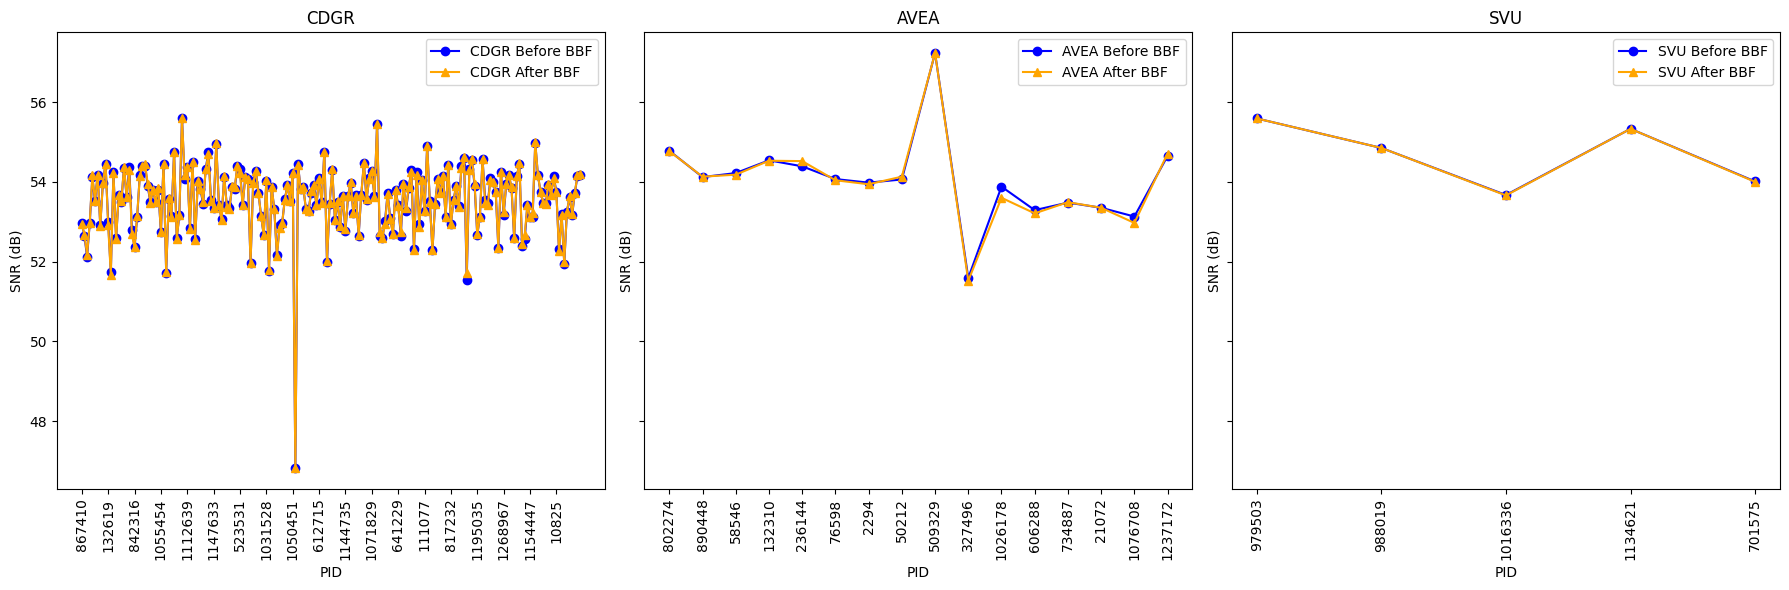

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the combined SNR CSV file
snr_df = pd.read_csv("/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/WaveformData/SNR_values_combined.csv")
# snr_df = pd.read_csv("/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/WaveformData/SNR_values_combined(test).csv")

# Extract PID from the 'File Name' column
snr_df['PID'] = snr_df['File Name'].apply(lambda x: x.split('_')[0])

# Plotting
plt.figure(figsize=(18, 6))

# Define the column mappings for each type
flow_columns = {
    "CDGR": {
        "before": "SNR_before_CDGR - Flow",
        "after": "SNR_after_CDGR - Flow"
    },
    "AVEA": {
        "before": "SNR_before_AVEA - Air Flow Wave",
        "after": "SNR_after_AVEA - Air Flow Wave"
    },
    "SVU": {
        "before": "SNR_before_SVU - Flow",
        "after": "SNR_after_SVU - Flow"
    }
}

# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Colors for before and after plots
colors = {'before': 'blue', 'after': 'orange'}

# Iterate over each ventilator type and plot
for ax, (dtype, snr_cols) in zip(axs, flow_columns.items()):
    # Check if columns exist
    if snr_cols["before"] not in snr_df.columns or snr_cols["after"] not in snr_df.columns:
        print(f"Skipping {dtype}: Missing columns.")
        continue

    # Filter non-null values for plotting
    subset_before = snr_df[snr_df[snr_cols["before"]].notna()]
    subset_after = snr_df[snr_df[snr_cols["after"]].notna()]
    subset = pd.concat([subset_before, subset_after]).drop_duplicates(subset='PID')

    # Plot before and after SNR
    ax.plot(subset['PID'], subset[snr_cols["before"]], label=f"{dtype} Before BBF", color=colors['before'], marker='o')
    ax.plot(subset['PID'], subset[snr_cols["after"]], label=f"{dtype} After BBF", color=colors['after'], marker='^')

    ax.set_title(dtype)
    ax.set_xlabel("PID")
    ax.set_ylabel("SNR (dB)")
    ax.tick_params(axis='x', rotation=90)
    
    # Adjust x-ticks:
    # For CDGR: Show every 10th PID
    if dtype == "CDGR":
        ticks_to_show = subset['PID'][::10]  # Show every 10th PID
        ax.set_xticks(subset['PID'][::10])
        ax.set_xticklabels(ticks_to_show, rotation=90)
    # For AVEA and SVU: Show only PIDs with data points
    else:
        ax.set_xticks(subset['PID'])
        ax.set_xticklabels(subset['PID'], rotation=90)

    ax.legend()

plt.tight_layout()
plt.show()


In [21]:
import pandas as pd

# Load the CSV file
file_path = '/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/WaveformData/SNR_values_combined.csv'
data = pd.read_csv(file_path)

# Select the relevant SNR columns (adjust as necessary based on the actual column names)
snr_columns = [
    'SNR_before_CDGR - Flow',
    'SNR_after_CDGR - Flow',
    'SNR_before_SVU - Flow',
    'SNR_after_SVU - Flow',
    'SNR_before_AVEA - Air Flow Wave',
    'SNR_after_AVEA - Air Flow Wave'
]

# For each SNR column, find the minimum value and the corresponding file name
for col in snr_columns:
    min_value = data[col].min()  # Find the minimum value
    min_value_row = data.loc[data[col].idxmin()]  # Find the row corresponding to the minimum value
    file_name = min_value_row['File Name']  # Get the file name for the minimum value
    print(f"Minimum SNR in column '{col}': {min_value}, File: {file_name}")


Minimum SNR in column 'SNR_before_CDGR - Flow': 46.82, File: 1195909_20240426_19_Waveform_1st.csv
Minimum SNR in column 'SNR_after_CDGR - Flow': 46.82, File: 1195909_20240426_19_Waveform_1st.csv
Minimum SNR in column 'SNR_before_SVU - Flow': 53.67, File: 1016336_20240507_17_Waveform_1st.csv
Minimum SNR in column 'SNR_after_SVU - Flow': 53.66, File: 1016336_20240507_17_Waveform_1st.csv
Minimum SNR in column 'SNR_before_AVEA - Air Flow Wave': 51.59, File: 327496_20230918_23_Waveform_1st.csv
Minimum SNR in column 'SNR_after_AVEA - Air Flow Wave': 51.52, File: 327496_20230918_23_Waveform_1st.csv


In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Path to the directory containing the CSV files
dir_path = '/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/WaveformData/01_Waveform_Raw_248_1st/FTandBBF_243_1st/'

# Path to the folder where images will be saved
image_dir = os.path.join(dir_path, 'Image(order3)')

# Create the Image directory if it doesn't exist
if not os.path.exists(image_dir):
    os.makedirs(image_dir)

# List all CSV files in the directory
csv_files = [f for f in os.listdir(dir_path) if f.endswith('.csv')]

# Helper function to determine data type from non-empty column names
def determine_data_type(df):
    for column_name in df.columns:
        if "CDGR - Flow" in column_name and df[column_name].notna().sum() > 0:
            return "CDGR", column_name
        elif "AVEA - Air Flow Wave" in column_name and df[column_name].notna().sum() > 0:
            return "AVEA", column_name
        elif "SVU - Flow" in column_name and df[column_name].notna().sum() > 0:
            return "SVU", column_name
    return None, None  # No valid non-empty column found

# Function to plot the flow columns as two subplots (one on top of the other) and save the plot
def plot_flow_columns(file_path, vent_type, flow_column, flow_ftandbbf_column):
    # Load the CSV file
    data = pd.read_csv(file_path)

    # Check if both columns are not empty
    if not data[flow_column].isna().all() and not data[flow_ftandbbf_column].isna().all():
        # Create subplots (2 rows, 1 column)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

        # Plot the Flow column on the first subplot
        ax1.plot(data[flow_column])
        ax1.set_title(f'{flow_column}')
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Flow')

        # Plot the Flow (FTandBBF) column on the second subplot
        ax2.plot(data[flow_ftandbbf_column], color='orange')
        ax2.set_title(f'{flow_ftandbbf_column}')
        ax2.set_xlabel('Time')
        ax2.set_ylabel('Flow (FTandBBF)')

        # Set the overall plot title
        plt.suptitle(f'Flow Comparison for {vent_type} - {os.path.basename(file_path)}', fontsize=16)

        # Save the plot as an image
        base_filename = os.path.splitext(os.path.basename(file_path))[0]  # Get the base file name without extension
        image_file_path = os.path.join(image_dir, f'{base_filename}_{vent_type}_Flow_Comparison.png')
        plt.savefig(image_file_path)
        plt.close()  # Close the plot to free memory

# Loop through all CSV files
for csv_file in csv_files:
    file_path = os.path.join(dir_path, csv_file)
    
    # Load the CSV file to check the columns
    df = pd.read_csv(file_path)
    
    # Use the helper function to determine the vent type and non-empty column
    vent_type, flow_column = determine_data_type(df)
    
    # If a valid vent type and column is found, look for the FTandBBF column
    if vent_type and flow_column:
        flow_ftandbbf_column = flow_column.replace('Flow', 'Flow (FTandBBF)')  # Assume the FTandBBF column follows this naming convention
        if flow_ftandbbf_column in df.columns:
            plot_flow_columns(file_path, vent_type, flow_column, flow_ftandbbf_column)